# Macro-Based Regime Detection

**Chapter 1 · §1.4 Market Regimes: Change Is the Constant**

**Docker image**: `ml4t`

## Purpose

Demonstrates unsupervised learning for market regime detection using macroeconomic
indicators from FRED, paired with S&P 500 volatility and drawdown for validation.

## Learning Objectives

- Cluster monthly macro indicators with GMM, K-Means, and hierarchical methods.
- Validate macro clusters against realized equity volatility and drawdown.
- Compare a four-indicator core view to an extended FRED panel.
- Use PCA preprocessing to filter noise before clustering.

## Book Reference

Section 1.4 of Chapter 1, "Market Regimes: Change Is the Constant" — macro-regime
follow-up to `factor_regimes.py`. Figure 1.6 in the chapter is generated here.

## Prerequisites

- Familiarity with monthly time-series resampling and standardization.
- Conceptual exposure to mixture models, K-Means, and dendrograms.
- FRED panel and S&P 500 daily series materialized via `data/macro/` and
  `data/equities/sp500/` loaders.

## Structure

1. **Core Analysis (4 indicators)** — UNRATE, DFF, T10Y2Y, CPIAUCSL → CPI YoY.
2. **Extended Analysis** — full FRED panel (after coverage filtering) for a richer
   but noisier view of economic conditions.
3. **Comparison** — silhouette scores across core, extended, and PCA-reduced models.

## Key Insight

Macro regimes line up with distinct *volatility* environments more cleanly than they
line up with average returns. This makes macro indicators useful for risk management
(anticipating volatility shifts) rather than return prediction.

## Imports

In [1]:
"""Macro-Based Regime Detection — unsupervised regime detection using FRED macro indicators."""

from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, scale

from data import load_macro, load_sp500_index
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults (Papermill overrides for testing)
SEED = 42

## Configuration

In [3]:
OUTPUT_DIR = get_output_dir(1, "macro_regimes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_global_seeds(SEED)

DATE_COL = "timestamp"

## Helper Function

Reusable function for regime visualization. Both GMM and K-Means results
use the same heatmap format for easy comparison.

In [4]:
def plot_regime_heatmap(
    assignments: np.ndarray,
    dates: pd.DatetimeIndex,
    title: str,
    n_regimes: int = 4,
    is_probability: bool = True,
    figsize: tuple = (14, 4),
) -> None:
    """
    Plot regime assignments as a heatmap.

    Parameters
    ----------
    assignments : np.ndarray
        Either probability matrix (n_samples, n_regimes) for GMM
        or hard labels (n_samples,) for K-Means
    dates : pd.DatetimeIndex
        Dates corresponding to each sample
    title : str
        Plot title
    n_regimes : int
        Number of regimes
    is_probability : bool
        True if assignments are probabilities, False for hard labels
    figsize : tuple
        Figure size
    """
    fig, ax = plt.subplots(figsize=figsize, layout="tight")

    # Convert hard labels to one-hot if needed
    if not is_probability:
        one_hot = np.zeros((len(assignments), n_regimes))
        one_hot[np.arange(len(assignments)), assignments] = 1
        data = one_hot
    else:
        data = assignments

    im = ax.imshow(data.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)

    # X-axis: years
    years = [pd.Timestamp(ts).year for ts in dates]
    year_ticks = [j for j, y in enumerate(years) if j == 0 or years[j - 1] != y]
    year_labels = [str(years[j]) for j in year_ticks]
    ax.set_xticks(year_ticks[::2])
    ax.set_xticklabels(year_labels[::2], fontsize=9)

    # Y-axis: regimes
    ax.set_yticks(range(n_regimes))
    ax.set_yticklabels([f"Regime {i + 1}" for i in range(n_regimes)])
    ax.set_ylabel("Regime")
    ax.set_xlabel("Year")
    ax.set_title(title, fontsize=12)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Probability" if is_probability else "Assignment")
    plt.show()

---

# Load FRED Macro Data

We load all available FRED macro indicators once, then select subsets for analysis.
The dataset includes ~17 series after filtering for data quality.

## Load Full Dataset

In [5]:
macro_raw = load_macro()

# group_by_dynamic requires Datetime, not Date
if macro_raw["timestamp"].dtype == pl.Date:
    macro_raw = macro_raw.with_columns(pl.col("timestamp").cast(pl.Datetime))

print(f"Loaded FRED macro data: {macro_raw.shape}")
print(f"Date range: {macro_raw['timestamp'].min()} to {macro_raw['timestamp'].max()}")
print(f"Available series: {[c for c in macro_raw.columns if c != 'timestamp']}")

Loaded FRED macro data: (9497, 26)
Date range: 2000-01-01 00:00:00 to 2025-12-31 00:00:00
Available series: ['dff', 'dgs1', 'dgs2', 'dgs3', 'dgs5', 'dgs7', 'dgs10', 'dgs20', 'dgs30', 't10y2y', 'vixcls', 'icsa', 'walcl', 'cpiaucsl', 'cpilfesl', 'pcepi', 'unrate', 'payems', 'civpart', 'indpro', 'm2sl', 'gdp', 'gdpc1', 'YIELD_CURVE_SLOPE', 'YIELD_CURVE_5_10']


## Available Indicators

| Category | Series | Description |
|----------|--------|-------------|
| **Labor** | UNRATE | Unemployment rate (%) |
| **Interest Rates** | DFF | Federal Funds effective rate (%) |
| | T10Y2Y | 10Y-2Y Treasury spread (yield curve) |
| | T10YIE | 10Y breakeven inflation |
| **Prices** | CPIAUCSL | Consumer Price Index |
| | CPILFESL | Core CPI (ex food & energy) |
| **Volatility** | VIXCLS | VIX volatility index |
| **Credit** | BAMLHE00EHYIEY | High yield spread |
| **Housing** | CSUSHPISA | Case-Shiller home price index |
| **Money** | M2SL | M2 money supply |

For the **Core Analysis**, we use only 4 fundamental macro indicators.

---

# Core Analysis: 4 Macro Indicators

We use four indicators that reflect real economic conditions:

- **UNRATE**: Unemployment rate - labor market health
- **DFF**: Federal Funds rate - monetary policy stance
- **T10Y2Y**: Yield curve slope - recession signal
- **CPIAUCSL → cpi_yoy**: CPI year-over-year inflation rate (not the level, which trends upward)

## Select Core Indicators

In [6]:
# Core 4 indicators (case-insensitive matching)
CORE_INDICATORS = ["unrate", "dff", "t10y2y", "cpiaucsl"]

macro_columns = macro_raw.columns
core_cols = []
col_name_map = {}

for indicator in CORE_INDICATORS:
    for col in macro_columns:
        if col.lower() == indicator:
            core_cols.append(col)
            col_name_map[col] = indicator
            break

print(f"Core indicators selected: {len(core_cols)}/{len(CORE_INDICATORS)}")
for col in core_cols:
    print(f"  {col} -> {col_name_map[col]}")

Core indicators selected: 4/4
  unrate -> unrate
  dff -> dff
  t10y2y -> t10y2y
  cpiaucsl -> cpiaucsl


## Resample to Monthly

In [7]:
macro_monthly = (
    macro_raw.select([DATE_COL] + core_cols)
    .sort(DATE_COL)
    .group_by_dynamic(DATE_COL, every="1mo", label="right")
    .agg([pl.col(c).last() for c in core_cols])
    # Forward-fill carries last observation through release lags; the small
    # backward-fill catches any leading nulls in early months. The latter
    # introduces a one-period look-ahead at the panel boundary — acceptable
    # for a regime-detection demo, not for a backtested strategy.
    .fill_null(strategy="forward")
    .fill_null(strategy="backward")
    .drop_nulls(subset=core_cols)
)

# Filter to 2002+ where most FRED series have good coverage
if macro_monthly.height > 0:
    min_date = macro_monthly[DATE_COL].min()
    if min_date is not None and str(min_date) < "2002-01-01":
        macro_monthly = macro_monthly.filter(pl.col(DATE_COL) >= pl.datetime(2002, 1, 1))

print(f"Monthly data: {macro_monthly.height} months")
if macro_monthly.height > 0:
    print(f"Date range: {macro_monthly[DATE_COL].min()} to {macro_monthly[DATE_COL].max()}")

Monthly data: 289 months
Date range: 2002-01-01 00:00:00 to 2026-01-01 00:00:00


## Standardize for Clustering

In [8]:
if macro_monthly.height > 0:
    macro_df = macro_monthly.select(core_cols).to_pandas()
    macro_df.columns = [col_name_map.get(c, c) for c in macro_df.columns]
    macro_df.index = macro_monthly[DATE_COL].to_pandas()

    # Convert CPI level to YoY percentage change — the level is non-stationary
    # and would make the clustering capture "early vs recent" rather than
    # "inflationary vs non-inflationary"
    macro_df["cpi_yoy"] = macro_df["cpiaucsl"].pct_change(12) * 100
    macro_df = macro_df.drop(columns=["cpiaucsl"]).dropna()

    macro_scaled = StandardScaler().fit_transform(macro_df)

    print("Core Indicator Statistics (raw):")
    print(macro_df.describe().round(2))
else:
    macro_df = pd.DataFrame()
    macro_scaled = np.array([])

Core Indicator Statistics (raw):
       unrate     dff  t10y2y  cpi_yoy
count  277.00  277.00  277.00   277.00
mean     5.75    1.76    1.07     2.58
std      2.02    1.91    0.97     1.81
min      3.40    0.04   -1.06    -1.96
25%      4.20    0.10    0.24     1.64
50%      5.00    1.04    1.01     2.33
75%      6.70    3.09    1.90     3.24
max     14.80    5.41    2.84     8.98


## Fit GMM with 4 Regimes

In [9]:
if len(macro_df) > 0:
    n_macro_regimes = 4
    gmm_macro = GaussianMixture(
        n_components=n_macro_regimes,
        covariance_type="full",
        random_state=SEED,
        n_init=10,
        reg_covar=1e-6,
    )
    gmm_macro.fit(macro_scaled)
    macro_labels = gmm_macro.predict(macro_scaled)
    macro_probs = gmm_macro.predict_proba(macro_scaled)

    macro_silhouette = silhouette_score(macro_scaled, macro_labels)
    print(f"Macro regime silhouette score (n={n_macro_regimes}): {macro_silhouette:.3f}")
else:
    macro_labels = np.array([])
    macro_probs = np.array([])

Macro regime silhouette score (n=4): 0.252


We use 4 regimes to match the Two Sigma approach. The silhouette score measures
cluster separation — higher is better, with values above 0.25 indicating
reasonable structure. Unlike factor_regimes, we skip BIC/AIC model selection here
because the goal is interpretability (matching known economic phases), not
statistical optimality.

## Regime Characteristics

In [10]:
if len(macro_df) > 0:
    regime_chars = macro_df.copy()
    regime_chars["regime"] = macro_labels
    regime_means = regime_chars.groupby("regime").mean()

    print("Regime Characteristics (mean values):")
    print(regime_means.round(2))
else:
    regime_means = pd.DataFrame()

Regime Characteristics (mean values):
        unrate   dff  t10y2y  cpi_yoy
regime                               
0         4.70  1.36    1.12     2.15
1        12.30  0.07    0.47     0.56
2         7.62  0.11    1.88     1.58
3         4.43  3.79    0.24     4.01


## Assign Interpretive Labels

In [11]:
def create_regime_labels(chars: pd.DataFrame) -> dict[int, str]:
    """Create short, descriptive labels based on economic characteristics.

    Uses a priority cascade on cluster-mean values. Thresholds are approximate
    and tuned for the 2002-2025 US macro environment.
    """
    labels = {}
    for regime in chars.index:
        c = chars.loc[regime]
        if c["unrate"] > 10:
            labels[regime] = "Crisis"
        elif c["unrate"] > 6 and c["dff"] < 0.5:
            labels[regime] = "Recovery"
        elif c["dff"] > 3 and c["t10y2y"] < 0.5:
            labels[regime] = "Tightening"
        elif c["cpi_yoy"] > 4:
            labels[regime] = "Inflation"
        elif c["unrate"] < 5 and c["dff"] < 2:
            labels[regime] = "Expansion"
        else:
            labels[regime] = "Transition"

    # Ensure unique labels
    seen = {}
    for r, label in list(labels.items()):
        if label in seen:
            if chars.loc[r, "unrate"] > chars.loc[seen[label], "unrate"]:
                labels[r] = f"{label} (High Unemp.)"
            else:
                labels[seen[label]] = f"{label} (High Unemp.)"
        seen[label] = r
    return labels

In [12]:
if len(regime_means) > 0:
    regime_labels_map = create_regime_labels(regime_means)
    print("Assigned Regime Labels:")
    for regime, label in sorted(regime_labels_map.items()):
        print(f"  Cluster {regime}: {label}")
else:
    regime_labels_map = {}

Assigned Regime Labels:
  Cluster 0: Expansion
  Cluster 1: Crisis
  Cluster 2: Recovery
  Cluster 3: Tightening


## Macro Regimes and Market Volatility

**Key insight**: Macro regimes coincide with different VOLATILITY environments,
even when return patterns are less clear.

**Implication**: Macro regime indicators are useful for RISK MANAGEMENT
(anticipating volatility shifts) rather than RETURN PREDICTION.

### Load S&P 500 for Validation

In [13]:
sp500_raw = load_sp500_index().to_pandas()
sp500_raw["timestamp"] = pd.to_datetime(sp500_raw["timestamp"])
sp500_raw = sp500_raw.set_index("timestamp")

sp500_monthly = sp500_raw["close"].resample("ME").last().to_frame()
sp500_monthly["returns"] = sp500_monthly["close"].pct_change()
sp500_df = sp500_monthly

print(
    f"Loaded S&P 500 for validation: {len(sp500_df)} months, "
    f"{sp500_df.index.min().date()} to {sp500_df.index.max().date()}"
)

Loaded S&P 500 for validation: 552 months, 1980-01-31 to 2025-12-31


### Compute Regime Statistics

In [14]:
if len(macro_df) > 0 and sp500_df is not None:
    events = {2008: "GFC", 2020: "COVID", 2022: "Inflation"}

    sp500_aligned = sp500_df.reindex(macro_df.index, method="nearest", tolerance=pd.Timedelta("5D"))
    sp500_aligned["regime"] = macro_labels
    sp500_aligned["regime_label"] = [regime_labels_map[r] for r in macro_labels]
    sp500_aligned["peak"] = sp500_aligned["close"].cummax()
    sp500_aligned["drawdown"] = (sp500_aligned["close"] - sp500_aligned["peak"]) / sp500_aligned[
        "peak"
    ]
    sp500_aligned["volatility"] = sp500_aligned["returns"].rolling(12).std() * np.sqrt(12)

    regime_stats_fig = sp500_aligned.groupby("regime_label").agg(
        {"returns": ["mean", "std", "count"], "drawdown": "min", "volatility": "mean"}
    )
    regime_stats_fig.columns = ["mean_ret", "std_ret", "months", "max_dd", "avg_vol"]
    regime_stats_fig["annual_vol"] = regime_stats_fig["std_ret"] * np.sqrt(12) * 100
    regime_stats_fig["max_dd_pct"] = -regime_stats_fig["max_dd"] * 100

    regime_stats_fig = regime_stats_fig.sort_values("annual_vol", ascending=True)
    regime_order = regime_stats_fig.index.tolist()
    n_regimes_fig = len(regime_order)

    print("Regime Statistics (sorted by volatility):")
    print(regime_stats_fig[["months", "annual_vol", "max_dd_pct"]].round(1))

Regime Statistics (sorted by volatility):
              months  annual_vol  max_dd_pct
regime_label                                
Expansion         77        12.0        14.6
Tightening        98        15.0        42.2
Recovery          98        15.2        52.6
Crisis             4        16.0         9.9


### Regime Timeline with Market Validation

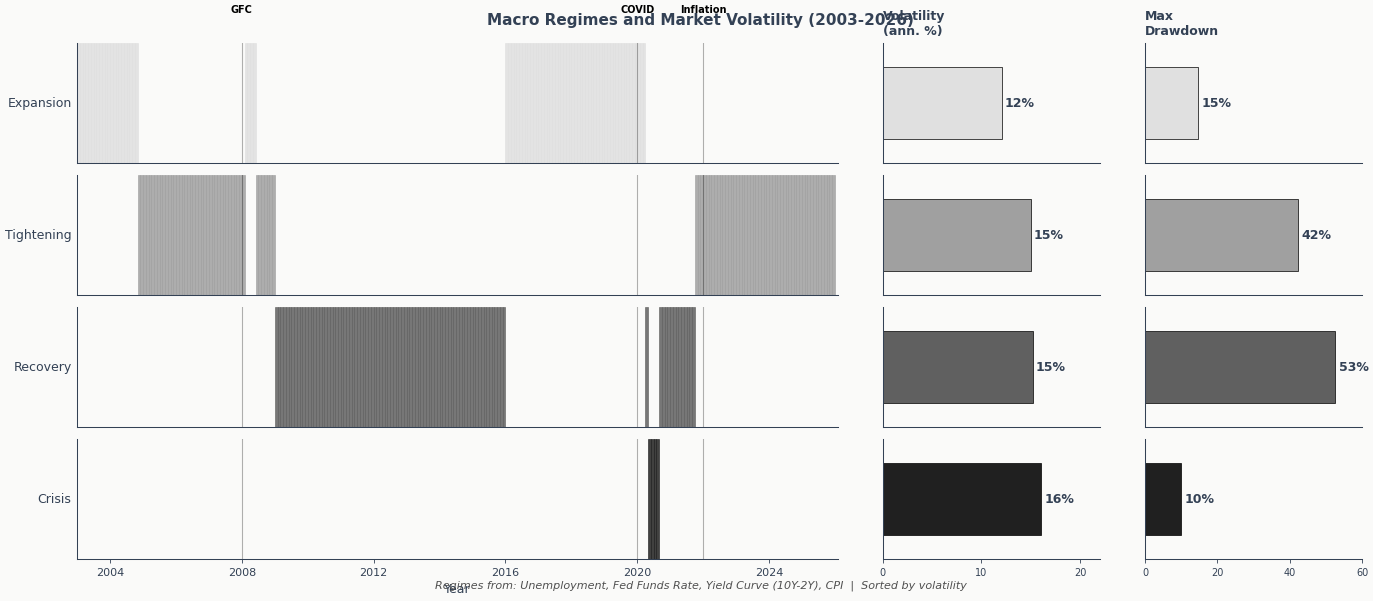

In [15]:
def plot_regime_timeline_validation():
    """Plot regime swim lanes with volatility and drawdown validation bars."""
    if len(macro_df) > 0 and sp500_df is not None:
        years = [pd.Timestamp(ts).year for ts in macro_df.index]
        n_months = len(macro_df)

        year_ticks = []
        year_labels_fig = []
        for j, year in enumerate(years):
            if j == 0 or years[j - 1] != year:
                if year % 4 == 0:
                    year_ticks.append(j)
                    year_labels_fig.append(str(year))

        fig = plt.figure(figsize=(14, 6))
        gs = GridSpec(
            n_regimes_fig, 4, figure=fig, width_ratios=[3.5, 1, 1, 0.05], wspace=0.12, hspace=0.08
        )

        swimlane_axes = [fig.add_subplot(gs[i, 0]) for i in range(n_regimes_fig)]
        vol_axes = [fig.add_subplot(gs[i, 1]) for i in range(n_regimes_fig)]
        dd_axes = [fig.add_subplot(gs[i, 2]) for i in range(n_regimes_fig)]

        # Grayscale-friendly palette (distinct in B&W print)
        # Ordered from light to dark to match volatility ordering
        REGIME_COLORS = ["#e0e0e0", "#a0a0a0", "#606060", "#202020"]
        colors = REGIME_COLORS[:n_regimes_fig]

        for i, regime_label in enumerate(regime_order):
            raw_regime = [r for r, lbl in regime_labels_map.items() if lbl == regime_label][0]
            mask = macro_labels == raw_regime
            stats = regime_stats_fig.loc[regime_label]
            color = colors[i]

            ax_swim = swimlane_axes[i]
            for j in range(n_months - 1):
                if mask[j]:
                    ax_swim.axvspan(j, j + 1, color=color, alpha=0.85)

            ax_swim.set_xlim(0, n_months)
            ax_swim.set_ylim(0, 1)
            ax_swim.set_yticks([])
            ax_swim.set_ylabel(regime_label, fontsize=9, rotation=0, ha="right", va="center")

            if i < n_regimes_fig - 1:
                ax_swim.set_xticks([])
            else:
                ax_swim.set_xticks(year_ticks)
                ax_swim.set_xticklabels(year_labels_fig, fontsize=8)
                ax_swim.set_xlabel("Year", fontsize=9)

            for event_year, event_label in events.items():
                try:
                    idx = next(j for j, y in enumerate(years) if y == event_year)
                    ax_swim.axvline(x=idx, color="black", linestyle="-", alpha=0.3, linewidth=0.8)
                    if i == 0:
                        ax_swim.annotate(
                            event_label,
                            xy=(idx, 1.25),
                            xycoords=("data", "axes fraction"),
                            ha="center",
                            fontsize=7,
                            color="black",
                            fontweight="bold",
                        )
                except StopIteration:
                    pass

            ax_vol = vol_axes[i]
            vol_val = stats["annual_vol"]
            ax_vol.barh([0], [vol_val], color=color, height=0.6, edgecolor="black", linewidth=0.5)
            ax_vol.set_xlim(0, 22)
            ax_vol.set_ylim(-0.5, 0.5)
            ax_vol.set_yticks([])
            ax_vol.text(
                vol_val + 0.3,
                0,
                f"{vol_val:.0f}%",
                ha="left",
                va="center",
                fontsize=9,
                fontweight="bold",
            )

            if i == 0:
                ax_vol.set_title("Volatility\n(ann. %)", fontsize=9, fontweight="bold")
            if i < n_regimes_fig - 1:
                ax_vol.set_xticks([])
            else:
                ax_vol.set_xticks([0, 10, 20])
                ax_vol.tick_params(labelsize=7)

            ax_dd = dd_axes[i]
            dd_val = stats["max_dd_pct"]
            ax_dd.barh([0], [dd_val], color=color, height=0.6, edgecolor="black", linewidth=0.5)
            ax_dd.set_xlim(0, 60)
            ax_dd.set_ylim(-0.5, 0.5)
            ax_dd.set_yticks([])
            ax_dd.text(
                dd_val + 1,
                0,
                f"{dd_val:.0f}%",
                ha="left",
                va="center",
                fontsize=9,
                fontweight="bold",
            )

            if i == 0:
                ax_dd.set_title("Max\nDrawdown", fontsize=9, fontweight="bold")
            if i < n_regimes_fig - 1:
                ax_dd.set_xticks([])
            else:
                ax_dd.set_xticks([0, 20, 40, 60])
                ax_dd.tick_params(labelsize=7)

        start_year = macro_df.index.min().year
        end_year = macro_df.index.max().year
        fig.suptitle(
            f"Macro Regimes and Market Volatility ({start_year}-{end_year})",
            fontsize=11,
            fontweight="bold",
            y=0.98,
        )

        fig.text(
            0.5,
            0.02,
            "Regimes from: Unemployment, Fed Funds Rate, Yield Curve (10Y-2Y), CPI  |  Sorted by volatility",
            ha="center",
            fontsize=8,
            style="italic",
            color="#505050",
        )

        plt.show()


plot_regime_timeline_validation()

### Persist Figure 1.6 inputs

The publication-quality version of Figure 1.6 is rendered by
`book/01_process_is_edge/figures/scripts/generate_figure_1_6_macro_regimes_volatility.py`.
That script reads the arrays persisted below so the book build does not
re-fit the clustering pipeline.

In [16]:
if len(macro_df) > 0 and sp500_df is not None:
    ARTIFACT_DIR = OUTPUT_DIR / "figure_1_6"
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    annual_vol_by_regime = regime_stats_fig.loc[regime_order, "annual_vol"].to_numpy(dtype=float)
    max_dd_by_regime = regime_stats_fig.loc[regime_order, "max_dd_pct"].to_numpy(dtype=float)
    np.savez(
        ARTIFACT_DIR / "inputs.npz",
        dates=macro_df.index.astype("datetime64[ns]").astype("int64"),
        macro_labels=np.asarray(macro_labels, dtype=np.int64),
        regime_order=np.asarray(regime_order, dtype=object),
        raw_regime_for_order=np.asarray(
            [
                next(r for r, lbl in regime_labels_map.items() if lbl == label)
                for label in regime_order
            ],
            dtype=np.int64,
        ),
        annual_vol=annual_vol_by_regime,
        max_dd_pct=max_dd_by_regime,
        event_years=np.asarray(list(events.keys()), dtype=np.int64),
        event_labels=np.asarray(list(events.values()), dtype=object),
        start_year=np.int64(macro_df.index.min().year),
        end_year=np.int64(macro_df.index.max().year),
    )

### Key Insight Summary

In [17]:
insight_table = (
    regime_stats_fig.loc[regime_order, ["months", "annual_vol", "max_dd_pct"]]
    .rename(
        columns={
            "months": "Months",
            "annual_vol": "Annual vol (%)",
            "max_dd_pct": "Max drawdown (%)",
        }
    )
    .round(1)
)
insight_table

,Months,Annual vol (%),Max drawdown (%)
regime_label,,,
Expansion,77,12.0,14.6
Tightening,98,15.0,42.2
Recovery,98,15.2,52.6
Crisis,4,16.0,9.9


## Correlation Heatmap

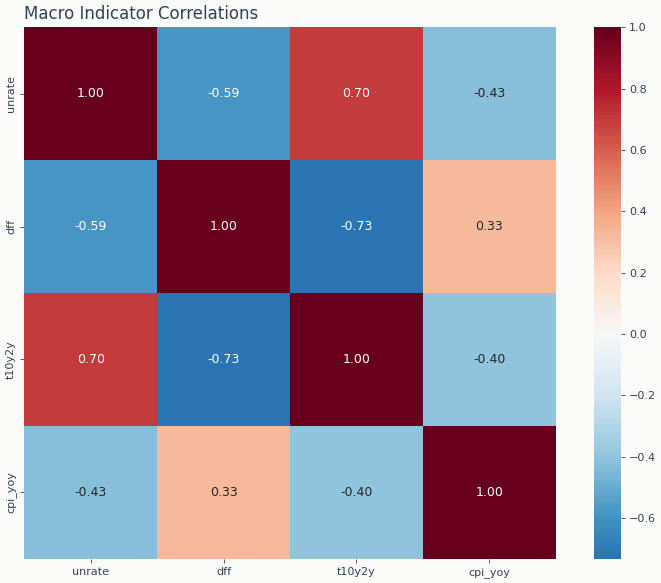

In [18]:
if len(macro_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 6), layout="tight")
    sns.heatmap(
        macro_df.corr(),
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        ax=ax,
        square=True,
    )
    ax.set_title("Macro Indicator Correlations", fontsize=12)
    plt.show()

**Interpretation**: Unemployment moves *with* the 10y-2y spread (positive
correlation ~0.70): when the labour market deteriorates, the curve typically
steepens as the Fed cuts the front end. The Fed Funds rate moves *against*
the spread (correlation ~−0.73): hiking cycles flatten or invert the curve.
CPI YoY is largely orthogonal to the other three — inflation regimes can
coexist with both recession and expansion. These pairwise correlations show
why a single indicator is a noisy regime signal and motivate joint clustering.

---

# Extended Analysis: All FRED Indicators

Now we expand beyond the 4 core indicators to use all available FRED series
(~17 indicators after quality filtering). This provides a richer but noisier
view of economic conditions.

## Prepare Full Dataset

Using the same data loaded at the start, we now select ALL series with
sufficient data coverage (< 50% missing).

In [19]:
# Use the already-loaded macro_raw data
value_cols_full = [c for c in macro_raw.columns if c != DATE_COL]

macro_monthly_full = (
    macro_raw.sort(DATE_COL)
    .group_by_dynamic(DATE_COL, every="1mo", label="right")
    .agg([pl.col(c).last() for c in value_cols_full])
    .filter(pl.col(DATE_COL) >= pl.datetime(2002, 1, 1))
)

# Identify columns with >50% missing, exclude market price columns
total_rows = macro_monthly_full.height
null_fractions = {
    col: macro_monthly_full.select(pl.col(col).is_null().sum()).item() / total_rows
    for col in value_cols_full
}
# Exclude columns with too much missing data and market price columns (SP500)
exclude_cols = {"sp500", "SP500"}
good_cols = [col for col, frac in null_fractions.items() if frac < 0.5 and col not in exclude_cols]

macro_clean_full = (
    macro_monthly_full.select([DATE_COL] + good_cols).fill_null(strategy="forward").drop_nulls()
)

macro_data_full = macro_clean_full.select(good_cols).to_pandas()
macro_data_full.index = macro_clean_full[DATE_COL].to_pandas()
macro_data_full = macro_data_full.apply(scale)

print(f"Extended dataset: {macro_data_full.shape[0]} months, {macro_data_full.shape[1]} series")
print(f"Series used: {list(macro_data_full.columns)}")

Extended dataset: 277 months, 25 series
Series used: ['dff', 'dgs1', 'dgs2', 'dgs3', 'dgs5', 'dgs7', 'dgs10', 'dgs20', 'dgs30', 't10y2y', 'vixcls', 'icsa', 'walcl', 'cpiaucsl', 'cpilfesl', 'pcepi', 'unrate', 'payems', 'civpart', 'indpro', 'm2sl', 'gdp', 'gdpc1', 'YIELD_CURVE_SLOPE', 'YIELD_CURVE_5_10']


## Visualize All Series

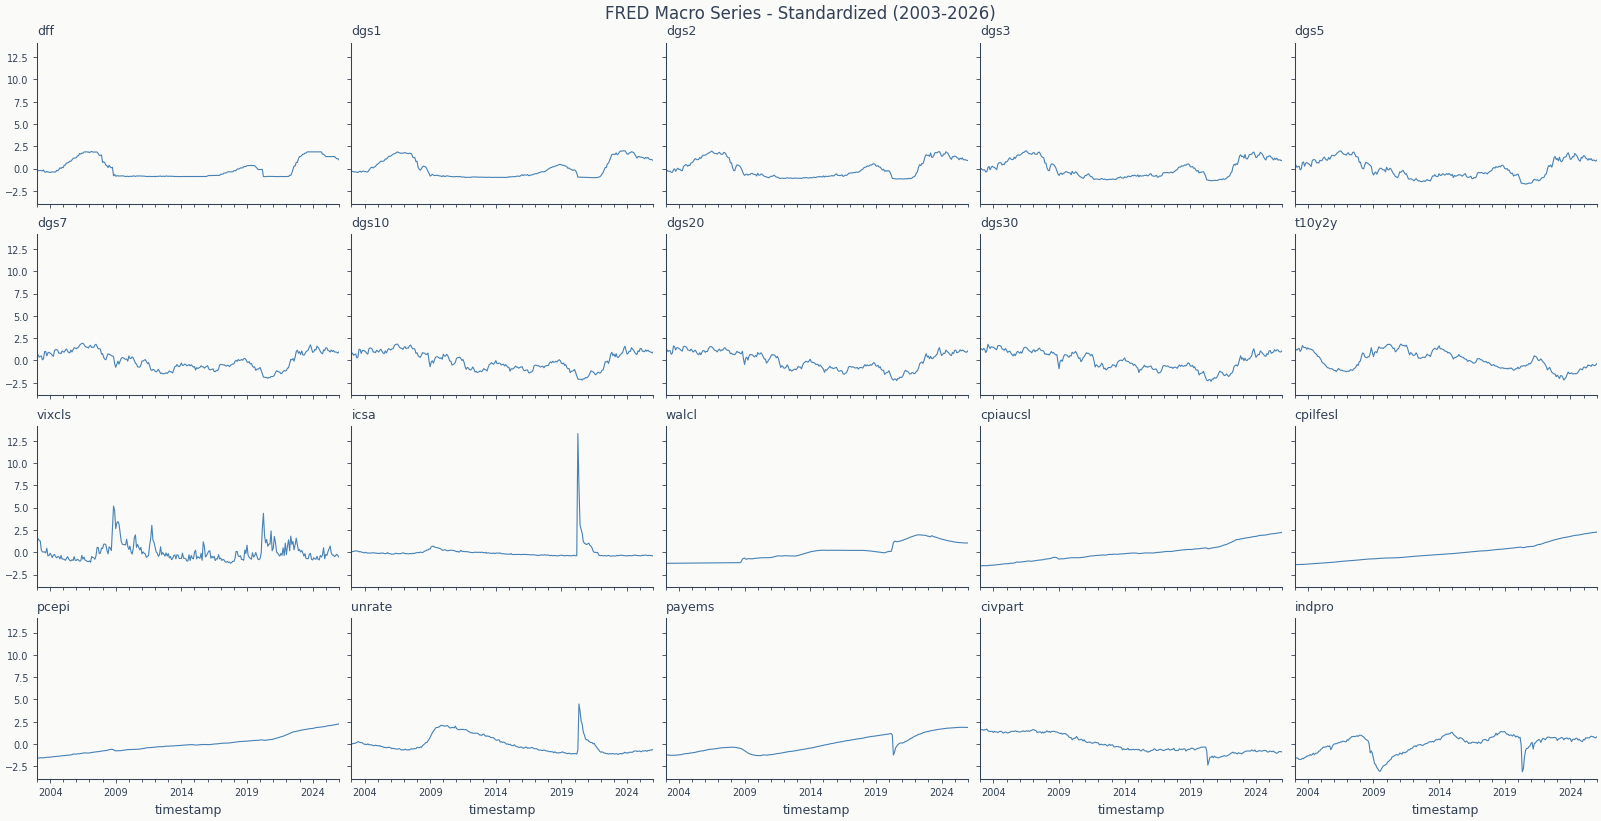

In [20]:
n_cols = min(len(macro_data_full.columns), 20)
n_rows = (n_cols + 4) // 5
n_plot_cols = min(5, n_cols)

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_plot_cols, figsize=(16, 2 * n_rows), sharex=True, sharey=True
)
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, ax in enumerate(axes[:n_cols]):
    if i < len(macro_data_full.columns):
        macro_data_full.iloc[:, i].plot(ax=ax, color="steelblue", linewidth=0.8)
        ax.set_title(macro_data_full.columns[i], fontsize=9)
        ax.tick_params(axis="both", labelsize=7)
    else:
        ax.set_visible(False)

for i in range(n_cols, len(axes)):
    axes[i].set_visible(False)

sns.despine()
start_yr = macro_data_full.index.min().year
end_yr = macro_data_full.index.max().year
fig.suptitle(f"FRED Macro Series - Standardized ({start_yr}-{end_yr})", fontsize=12, y=1.02)
plt.show()

**Interpretation**: The visibly regime-bearing series are VIX (sharp spikes
in 2008 and 2020), ICSA initial claims (same crisis peaks), DFF (regime
shifts during hiking cycles), and the yield-curve spread T10Y2Y (recession
warnings ahead of 2008 and 2020). Slow-moving series (housing, monetary
aggregates) carry less regime information. Clustering will lean heavily on
the high-variance subset.

## Hierarchical Clustering

Cluster the correlation matrix to reveal indicator groupings.

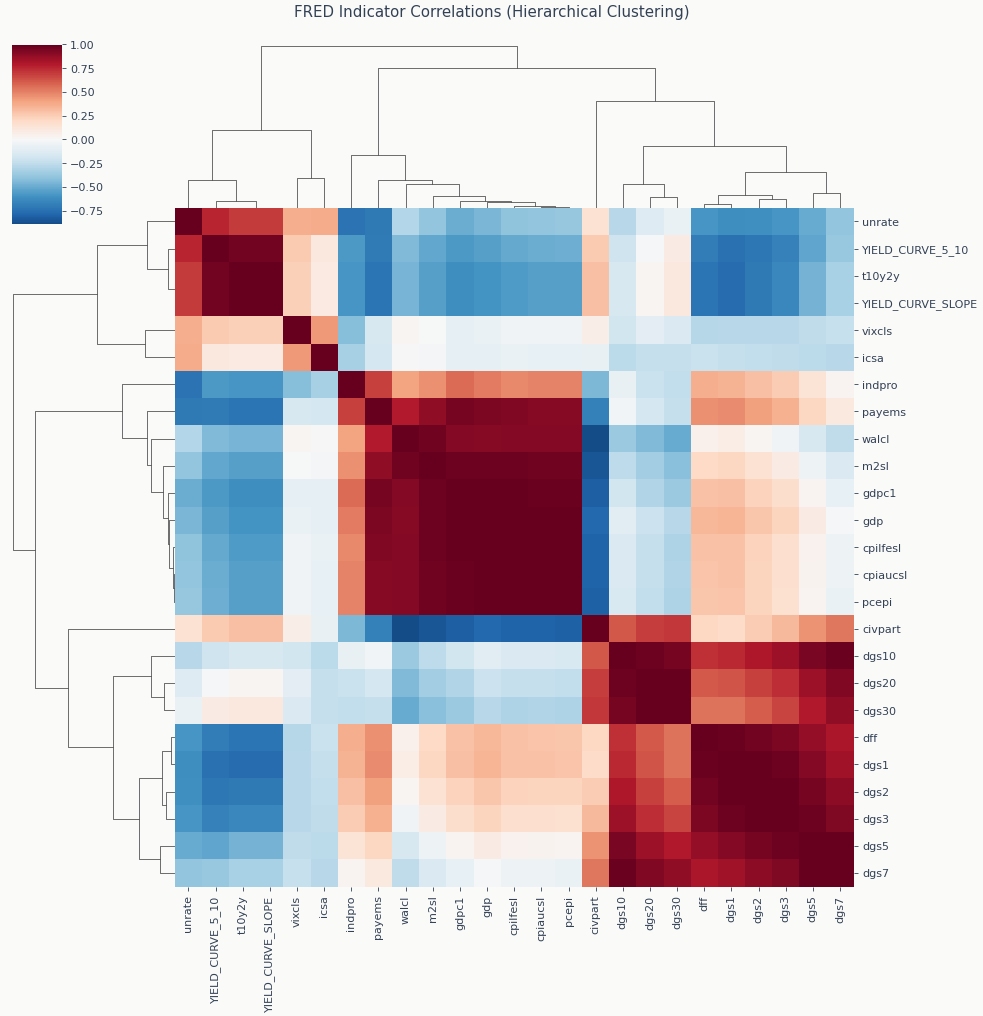

In [21]:
# clustermap manages its own gridspec; disable constrained_layout to avoid
# matplotlib colorbar/engine-switch errors under non-interactive backends.
with plt.rc_context({"figure.constrained_layout.use": False}):
    fig = sns.clustermap(macro_data_full.corr(), cmap="RdBu_r", center=0, figsize=(10, 10))
    fig.fig.suptitle("FRED Indicator Correlations (Hierarchical Clustering)", y=1.02)
    plt.show()

**Interpretation**: Four blocks emerge: a labour/yield-curve block
(CIVPART, UNRATE, T10Y2Y), a stress block (VIX, ICSA, high-yield spread), a
growth/price-level block (INDPRO, CPI, M2), and a short-rate block
(DFF, T10YIE). Most off-diagonal correlations are modest in magnitude, and
the dendrogram's high cophenetic correlation confirms that this block
structure is genuinely hierarchical.

## Comparing GMM and K-Means

Both methods identify 4 regimes. The key difference:
- **GMM**: Soft assignments with probabilities (uncertainty quantified)
- **K-Means**: Hard assignments (each month belongs to exactly one regime)

### Fit Both Models

In [22]:
n_regimes_full = 4

# GMM
gmm_full = GaussianMixture(
    n_components=n_regimes_full,
    covariance_type="full",
    random_state=SEED,
    n_init=10,
    reg_covar=1e-6,
)
gmm_full.fit(macro_data_full)
gmm_probs_full = gmm_full.predict_proba(macro_data_full)
gmm_labels_full = gmm_full.predict(macro_data_full)

# K-Means
kmeans_full = KMeans(n_clusters=n_regimes_full, random_state=SEED, n_init=10)
kmeans_labels_full = kmeans_full.fit_predict(macro_data_full)

print(f"GMM silhouette: {silhouette_score(macro_data_full, gmm_labels_full):.3f}")
print(f"K-Means silhouette: {silhouette_score(macro_data_full, kmeans_labels_full):.3f}")

GMM silhouette: 0.417
K-Means silhouette: 0.448


### GMM Regime Probabilities

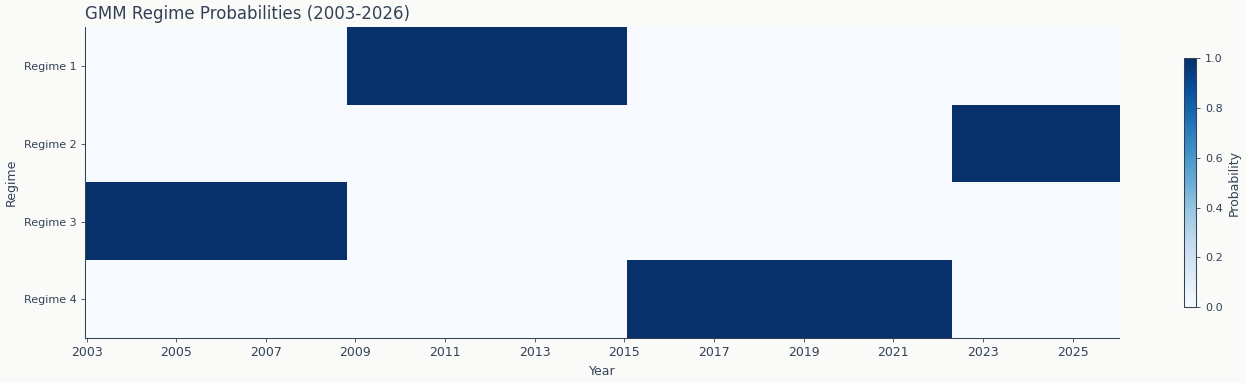

In [23]:
plot_regime_heatmap(
    gmm_probs_full,
    macro_data_full.index,
    f"GMM Regime Probabilities ({start_yr}-{end_yr})",
    n_regimes=n_regimes_full,
    is_probability=True,
)

### K-Means Regime Assignments

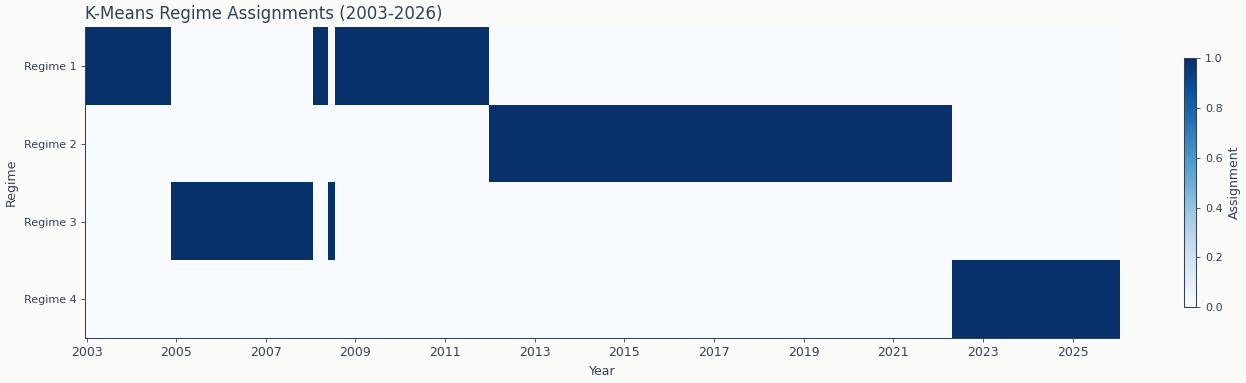

In [24]:
plot_regime_heatmap(
    kmeans_labels_full,
    macro_data_full.index,
    f"K-Means Regime Assignments ({start_yr}-{end_yr})",
    n_regimes=n_regimes_full,
    is_probability=False,
)

## Agglomerative Clustering

Hierarchical clustering on observations (not features) shows how months group together.

### Linkage Matrix

In [25]:
Z_full = linkage(macro_data_full, "ward")
pairwise_dist = pdist(macro_data_full)
c, _ = cophenet(Z_full, pairwise_dist)

print(f"Cophenetic correlation: {c:.3f}")

Cophenetic correlation: 0.710


**Note**: The cophenetic correlation measures how faithfully the dendrogram
preserves the original pairwise distances; good dendrograms score above 0.7.
Here it reaches 0.71, so the Ward-linkage tree is a reliable summary of the
indicator distance structure — the block grouping above reflects real
hierarchy rather than an artefact of the linkage choice.

### Dendrogram

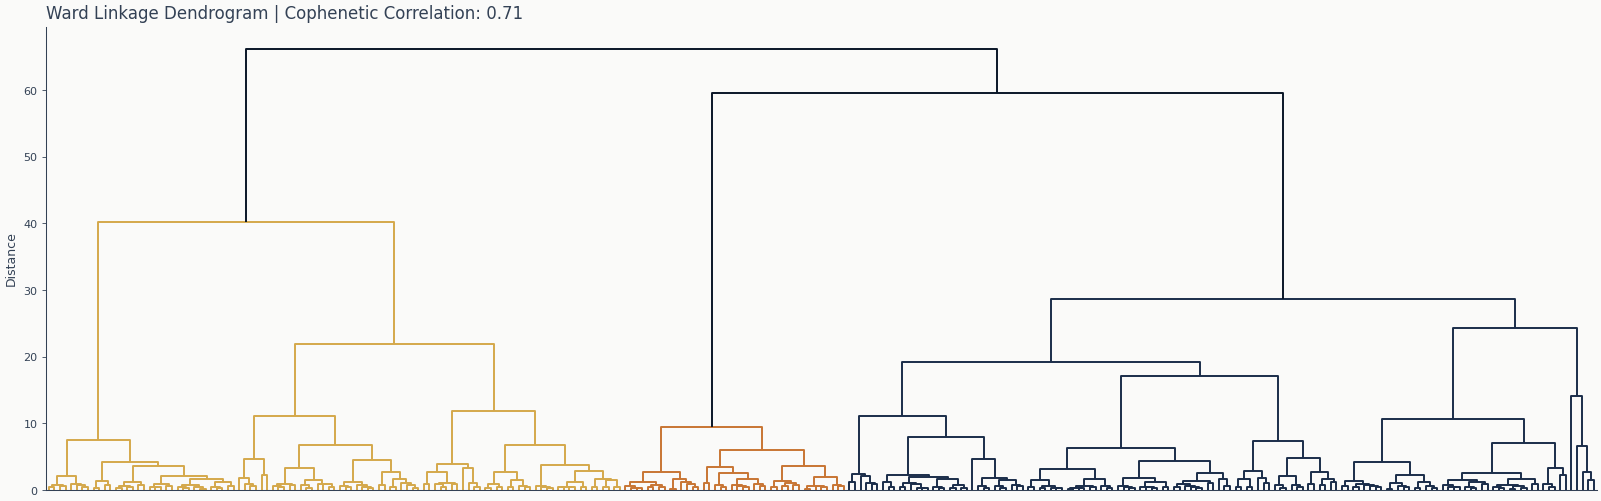

In [26]:
fig, ax = plt.subplots(figsize=(16, 5))
# no_labels=True since the point of this figure is the cophenetic-correlation
# summary in the title, not per-observation identity.
dendrogram(Z_full, orientation="top", no_labels=True, ax=ax)
ax.set_title(f"Ward Linkage Dendrogram | Cophenetic Correlation: {c:.2f}", fontsize=12)
ax.set_ylabel("Distance")
sns.despine()
plt.show()

## PCA Preprocessing

Reduce dimensionality before clustering to filter noise.

### Fit PCA

In [27]:
n_pca = min(10, macro_data_full.shape[1])
pca = PCA(n_components=n_pca)
reduced = pca.fit_transform(macro_data_full)

print("Cumulative Explained Variance:")
cumvar = pd.Series(pca.explained_variance_ratio_).cumsum()
for i, v in enumerate(cumvar):
    print(f"  PC{i + 1}: {v:.1%}")

Cumulative Explained Variance:
  PC1: 45.6%
  PC2: 80.4%
  PC3: 87.9%
  PC4: 93.6%
  PC5: 96.0%
  PC6: 97.8%
  PC7: 98.8%
  PC8: 99.4%
  PC9: 99.7%
  PC10: 99.8%


### GMM on PCA-Reduced Data

In [28]:
gmm_pca = GaussianMixture(
    n_components=n_regimes_full,
    covariance_type="full",
    random_state=SEED,
    n_init=10,
    reg_covar=1e-6,
)
gmm_pca.fit(reduced)
pca_probs = gmm_pca.predict_proba(reduced)
pca_labels = gmm_pca.predict(reduced)

print(f"GMM on PCA silhouette: {silhouette_score(reduced, pca_labels):.3f}")

GMM on PCA silhouette: 0.396


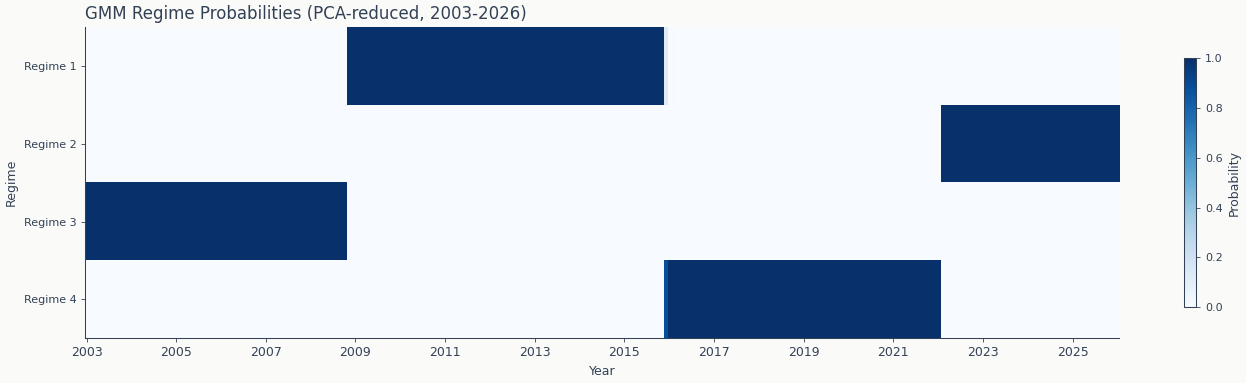

In [29]:
plot_regime_heatmap(
    pca_probs,
    macro_data_full.index,
    f"GMM Regime Probabilities (PCA-reduced, {start_yr}-{end_yr})",
    n_regimes=n_regimes_full,
    is_probability=True,
)

---

# Comparison: 4 Indicators vs Extended Dataset

How do results differ between the simple (4-indicator) and extended approaches?

## Visual Comparison

Side-by-side heatmaps showing regime probabilities from both approaches.

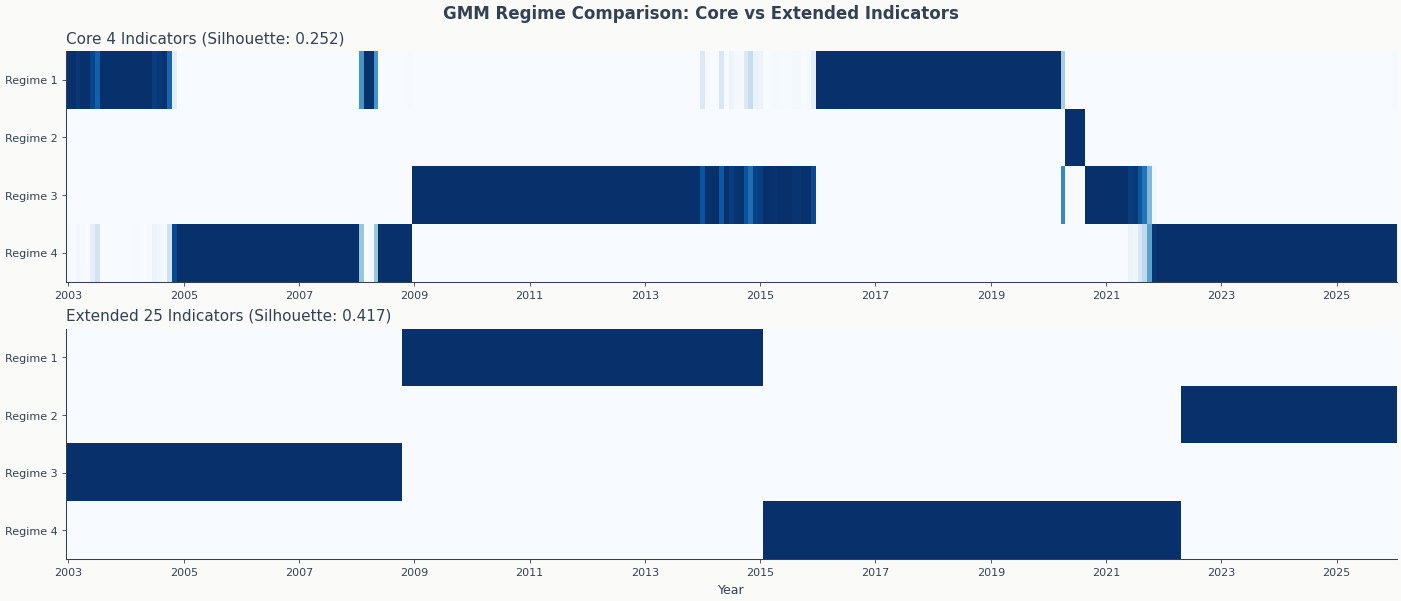

In [30]:
# Create side-by-side comparison (if both datasets available)
if len(macro_probs) > 0 and len(gmm_probs_full) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))

    # Panel 1: Core 4 indicators
    ax1 = axes[0]
    im1 = ax1.imshow(macro_probs.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    years_core = [pd.Timestamp(ts).year for ts in macro_df.index]
    year_ticks_core = [j for j, y in enumerate(years_core) if j == 0 or years_core[j - 1] != y]
    year_labels_core = [str(years_core[j]) for j in year_ticks_core]
    ax1.set_xticks(year_ticks_core[::2])
    ax1.set_xticklabels(year_labels_core[::2], fontsize=8)
    ax1.set_yticks(range(n_macro_regimes))
    ax1.set_yticklabels([f"Regime {i + 1}" for i in range(n_macro_regimes)])
    ax1.set_title(f"Core 4 Indicators (Silhouette: {macro_silhouette:.3f})", fontsize=11)

    # Panel 2: Extended dataset
    ax2 = axes[1]
    im2 = ax2.imshow(gmm_probs_full.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    years_ext = macro_data_full.index.year.tolist()
    year_ticks_ext = [j for j, y in enumerate(years_ext) if j == 0 or years_ext[j - 1] != y]
    year_labels_ext = [str(years_ext[j]) for j in year_ticks_ext]
    ax2.set_xticks(year_ticks_ext[::2])
    ax2.set_xticklabels(year_labels_ext[::2], fontsize=8)
    ax2.set_yticks(range(n_regimes_full))
    ax2.set_yticklabels([f"Regime {i + 1}" for i in range(n_regimes_full)])
    ax2.set_xlabel("Year")
    ext_sil = silhouette_score(macro_data_full, gmm_labels_full)
    ax2.set_title(
        f"Extended {macro_data_full.shape[1]} Indicators (Silhouette: {ext_sil:.3f})", fontsize=11
    )

    fig.suptitle(
        "GMM Regime Comparison: Core vs Extended Indicators", fontsize=12, fontweight="bold"
    )
    plt.show()
else:
    print("Comparison visualization skipped - insufficient data")

## Quantitative Comparison

In [31]:
core_sil = macro_silhouette if len(macro_df) > 0 else float("nan")
extended_sil = silhouette_score(macro_data_full, gmm_labels_full)
pca_sil = silhouette_score(reduced, pca_labels)

silhouette_compare = pd.DataFrame(
    {
        "Model": [
            "Core (4 indicators)",
            f"Extended ({macro_data_full.shape[1]} indicators)",
            "Extended + PCA",
        ],
        "Silhouette": [core_sil, extended_sil, pca_sil],
    }
).set_index("Model")

if core_sil > extended_sil:
    interpretation = "Core 4 indicators provide cleaner separation; additional series add noise."
else:
    interpretation = (
        "Extended indicators provide better separation; the broader panel captures "
        "meaningful economic variation despite added noise."
    )
print(interpretation)
silhouette_compare.style.format("{:.3f}")

Extended indicators provide better separation; the broader panel captures meaningful economic variation despite added noise.


,Silhouette
Model,
Core (4 indicators),0.252
Extended (25 indicators),0.417
Extended + PCA,0.396


## Key Takeaways

- **Macro indicators line up with realised volatility**: The four regimes' mean
  annualised volatility runs from 12.0% (Expansion, 77 months) to 16.0% (Crisis,
  4 months), with Tightening at 15.0% and Recovery at 15.2%. The Crisis cell
  covers only 4 months on this 2003-2026 panel, so the 16.0% figure is an
  anecdotal upper bound rather than a regime-level statistic.
- **Extended indicators improve cluster quality**: The 25-indicator model achieves
  higher silhouette (0.42) than the 4-indicator model (0.25), but the core model
  is more interpretable — the trade-off depends on the use case.
- **Hierarchical structure is genuine**: A cophenetic correlation of 0.71, above the
  0.7 quality bar, means the dendrogram faithfully represents the indicator distance
  structure rather than imposing an arbitrary tree.
- **Use rates, not levels**: We use CPI year-over-year change rather than the CPI level,
  because clustering on a trending level would capture "early vs late" rather than
  "inflationary vs non-inflationary."
- **GMM vs K-Means**: Similar performance (silhouette 0.42 vs 0.45), but GMM provides
  probability assignments that quantify regime uncertainty.

**Book reference**: §1.4 of Chapter 1 frames these regimes as inputs to risk
management — exposure caps, hedging triggers, and de-risking rules — rather than
as return forecasts. Figure 1.6 in the chapter is the macro-regime panel rendered
above.